<a href="https://colab.research.google.com/github/YefridC09/ST-554-Project1-Template/blob/main/Task2/st554_project1_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Author: Eleanor Warren

Date: 2/23/2026

Purpose: Task 2

# **Task 2: Exploratory Data Analysis**
In this section of our project, we will investigate our dataset further. These data are accessed at the UC Irvine Machine Learning Repository, and contain air quality measurements collected over a 12 month period (March 2004 to February 2005) from a city in Italy. To get a baseline understanding of how this data was collected and for what purpose, I refer to _**On field calibration of an electronic nose for benzene estimation in an urban pollution monitoring scenario**_ (S. De Vito, E. Massera, M. Piga, L. Martinotto, G. Di Francia).

## **Background Information**
This dataset contains hourly averaged levels of gas concentrations, as measured by a number of 5 metal oxide sensors embedded in an "Air Quality Chemical Multisensor Device" that was placed in a "significantly polluted area" in Italy, from 2004-2005. These sensors, which the paper refers to as "electronic noses," are each slightly adjusted to be more sensitive/better at measuring one particular gas, but they are all measuring the following gases: CO, Non Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx) and Nitrogen Dioxide (NO2).

According to _**On field calibration**_, the purpose of collecting this data was to investigate whether the "electronic noses" could be a supplemental tool in measuring gas levels, in addition to the "ground truth" (gold-standard) analyzers already used in the field. They assessed the quality of the sensor measurements by performing analysis with the ground truth measures as a comparison. In particular, they wanted to see if these sensors were a useful tool for measuring benzene concentrations, particularly because benzene has been shown to induce cancers. Broadly, the goal of collecting this data is to see if electronic noses can help gather reliable polllutant data.

##**High-level Statistics**
This dataset contains 9358 observations and contains missing values, denoted by `-200`

##**Questions to Investigate**
- How is the data stored?
- How does temperature and humidity impact measured benzene concentrations?

In [44]:
!pip install ucimlrepo

## modify column names or do other manipulations

##**How is the data stored?**

The full dataset is stored as a dictionary with the keys `data`, `metadata`, and `variables`. We can access the dataset through the UCI GitHub `ucimlrepo` repository. The data itself is stored as a pandas dataframe with 15 variables.

Below we save the repo dictionary as `air_quality` so we can access all of its keys.

In [45]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime as dt

# Keep air_quality as our repo dictionary
air_quality = fetch_ucirepo(id=360)
type(air_quality)

ucimlrepo.dotdict.dotdict

##**What's in the Metadata?**

This includes the unique UCI dataset identifier, name and data description, repo link, raw data file link, dataset abstract, and more.

In [46]:
print(list(air_quality.metadata.keys()))

['uci_id', 'name', 'repository_url', 'data_url', 'abstract', 'area', 'tasks', 'characteristics', 'num_instances', 'num_features', 'feature_types', 'demographics', 'target_col', 'index_col', 'has_missing_values', 'missing_values_symbol', 'year_of_dataset_creation', 'last_updated', 'dataset_doi', 'creators', 'intro_paper', 'additional_info']


We can also look at the list of variables. This is great because it contains the units of measurement.

In [47]:
print(air_quality.variables)

             name     role         type demographic  \
0            Date  Feature         Date        None   
1            Time  Feature  Categorical        None   
2          CO(GT)  Feature      Integer        None   
3     PT08.S1(CO)  Feature  Categorical        None   
4        NMHC(GT)  Feature      Integer        None   
5        C6H6(GT)  Feature   Continuous        None   
6   PT08.S2(NMHC)  Feature  Categorical        None   
7         NOx(GT)  Feature      Integer        None   
8    PT08.S3(NOx)  Feature  Categorical        None   
9         NO2(GT)  Feature      Integer        None   
10   PT08.S4(NO2)  Feature  Categorical        None   
11    PT08.S5(O3)  Feature  Categorical        None   
12              T  Feature   Continuous        None   
13             RH  Feature   Continuous        None   
14             AH  Feature   Continuous        None   

                                          description       units  \
0                                                N

Now, we save the actual data, the "features" of the dataset, to a separate object for us to analyze.

In [48]:
# Saving the actual data (features) to a separate object for us to analyze. This is
# saved as a pandas dataframe.
air_data_full = air_quality.data.features

We see some of the same information about our variables here, but now with the object types, like `float64`

In [49]:
# Get the list of variables in the data set
air_data_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


##**Cleaning up the Dataset**
Since we're going to do some analysis on our data, we should rename the columns into something that is more compatible with python, in particular by removing symbols.


In [50]:
# Get variable names in a more compatible format for python by removing certain symbols

# First rename the "ground truth" variables
# NOTE: naming C6H6 (benzene) differently since we want to keep that one later on
air_data_full = air_data_full.rename(columns={"CO(GT)" : "CO_GT", "NMHC(GT)" : "NMHC_GT", \
                                    "C6H6(GT)" : "C6H6", "NOx(GT)" : "NOx_GT", \
                                    "NO2(GT)" : "NO2_GT"})
# Rename the raw sensor readings
air_data_full = air_data_full.rename(columns={"PT08.S1(CO)" : "CO_S1", "PT08.S2(NMHC)" : "NMHC_S2", \
                                    "PT08.S3(NOx)" : "NOx_S3", "PT08.S4(NO2)" : "NO2_S4", \
                                    "PT08.S5(O3)" : "O3_S5"})
# Take a look at the first few entries
air_data_full.head()


,Date,Time,CO_GT,CO_S1,NMHC_GT,C6H6,NMHC_S2,NOx_GT,NOx_S3,NO2_GT,NO2_S4,O3_S5,T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Just by looking at the first few data points, it stood out to me that the magnitude of the "ground truth" average hourly concentrations of certain chemicals (from "co-located reference certified analyzer[s]") seemed to be much smaller than the magnitude of the corresponding hourly averaged sensor responses. This is related to the cross-sensitivites of these sensors, and makes sense in the context of what this paper is trying to investigate, which is whether these sensors can be good supplemental tools for measuring gas concentrations anyway. However, we aren't going to be investigating the "ground truth" values other than Benzene (C6H6), so I will drop those from the dataset.

In [51]:
# Use list comprehension to drop the "ground truth" variables
droplist = [var for var in air_data_full.columns if "_GT" in var]
print(droplist)

# Save our streamlined dataframe to air_data
air_data = air_data_full.drop(columns = droplist)

['CO_GT', 'NMHC_GT', 'NOx_GT', 'NO2_GT']


For some additional data cleaning, we'll identify and recode missing variables, then drop them from the dataset. Here, we recode `-200` to `NaN`

In [52]:
# Represents missing values
air_data = air_data.replace(to_replace = -200, value = np.nan)

# Check out last few values
air_data.tail()

,Date,Time,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH
9352,4/4/2005,10:00:00,1314.0,13.5,1101.0,539.0,1374.0,1729.0,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,1163.0,11.4,1027.0,604.0,1264.0,1269.0,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,1142.0,12.4,1063.0,603.0,1241.0,1092.0,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,1003.0,9.5,961.0,702.0,1041.0,770.0,28.3,13.5,0.5139
9356,4/4/2005,14:00:00,1071.0,11.9,1047.0,654.0,1129.0,816.0,28.5,13.1,0.5028


Before we drop the missing values, let's get a sense of how many there are in the data.

In [53]:
# Sum the number of missing values for each variable
air_data.isnull().sum()

,0
Date,0
Time,0
CO_S1,366
C6H6,366
NMHC_S2,366
NOx_S3,366
NO2_S4,366
O3_S5,366
T,366
RH,366


It looks like all of the measured variables have 366 missing values.

In [54]:
# Now let's drop the missing values
air_data_clean = air_data.dropna()

We should do some basic data validation here by assessing if these statistics make sense now that we've dropped missing values from the data. The only thing that stands out as odd initially is the negative value for "T", but since that is the variable for temperature, and we can have negative temperatures, it's reasonable to assume that's not a data error.

Below we use .describe(), which only provides some statistics for numeric data, excluding date and time here.

In [55]:
# Quick overview analysis of all the numeric variables (everything but date and time)
summary_tab = air_data_clean.describe(percentiles = [0.10, 0.25, 0.50, 0.75, 0.90])
summary_tab

,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,1099.833166,10.083105,939.153376,835.493605,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,217.080037,7.449820,266.831429,256.817320,346.206794,398.484288,8.832116,17.316892,0.403813
min,647.000000,0.100000,383.000000,322.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
10%,851.000000,2.500000,618.000000,536.000000,984.000000,544.000000,6.900000,25.300000,0.470800
25%,937.000000,4.400000,734.500000,658.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1063.000000,8.200000,909.000000,806.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,1231.000000,14.000000,1116.000000,969.500000,1674.000000,1273.500000,24.400000,62.500000,1.313700
90%,1411.000000,20.300000,1305.000000,1155.000000,1894.000000,1589.000000,30.300000,72.600000,1.586800
max,2040.000000,63.700000,2214.000000,2683.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


I plan to use some of these statistics later in my analysis, so I've saved this summary table as an object. This table contains the number of observations, mean, standard deviation, minimum, 10th/25th/50th/75th/90th percentile, and max values for each gas concentration, as measured by the "electronic nose", as well as for temperature, relative humidity, and absolute humidity.



##**Diving into Benzene (C6H6)**
###**Tables and Plots of Benzene Only**

Focusing on benzene (C6H6) specifically, we can get a picture of the measures of center and spread here. We will also include a quick histogram to understand the shape of the distribution of values. Below we print out some numeric summary statistics again, but just for benzene. We see that the measured benzene concentration ranges from 0.1 to 63.7 microg/m^3.

In [56]:
# Numeric summaries of benzene
air_data_clean[["C6H6"]].describe(percentiles = [0.05, 0.25, 0.50, 0.75, 0.99])

,C6H6
count,8991.000000
mean,10.083105
std,7.449820
min,0.100000
5%,1.700000
25%,4.400000
50%,8.200000
75%,14.000000
99%,34.310000
max,63.700000


Visualize the shape of our data by plotting benzene as a histogram. It looks like most of the measured values are observed around 8 microg/m^3, with a tail that is skewed to the right. That signals that there might be some outliers in the dataset towards the higher benzene concentrations.

[Text(0.5, 0, 'C6H6')]

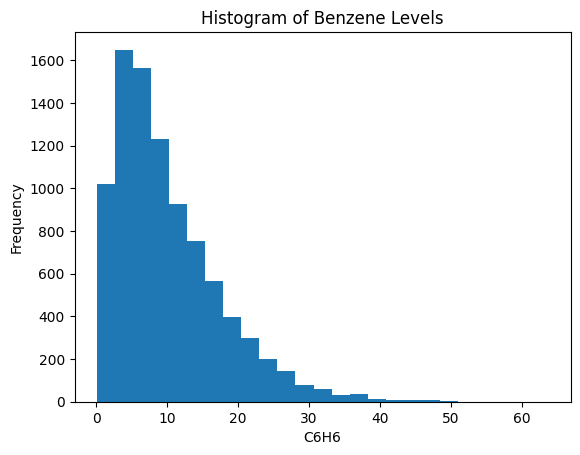

In [57]:
# Histogram of C6H6
air_data_clean.C6H6.plot.hist(bins = 25, title = "Histogram of Benzene Levels") \
    .set(xlabel = "C6H6")

Below is a line plot of benzene (C6H6) over all of the dates observed. This is a really noisy chart, so let's see it at a lower time frequency.


Text(0, 0.5, 'microg/m^3')

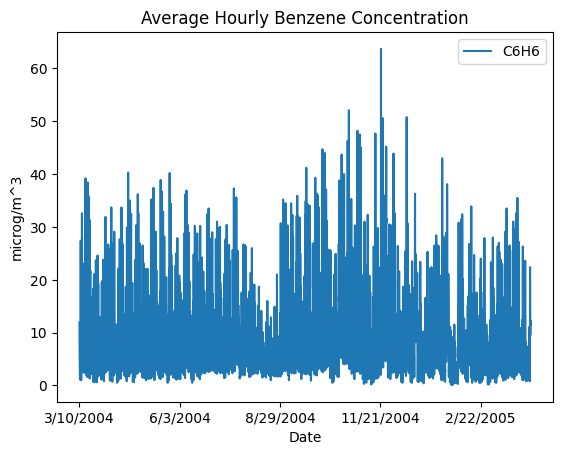

In [58]:
# Leverage pandas simple .plot() function for time series
air_data_clean.plot("Date", "C6H6")
plt.title("Average Hourly Benzene Concentration")
plt.ylabel("microg/m^3")

In order to view benzene at a lower time frequency, I need to use the date variable to create a month-year only date, and then find the average for each month. I can't just extract the month by itself since our dataset spans a year and we want to ensure that we don't combine March from 2004 with March from 2005, for example. I don't think it would happen here since we only have March to February, but we want our code to be flexible.

In [59]:
# Create a month variable

# Combined information from the following sources:

# Source - https://stackoverflow.com/a/72181248
# Posted by jezrael
# Retrieved 2026-02-17, License - CC BY-SA 4.0

# Source - https://stackoverflow.com/a/59251840
# Posted by ATL
# Retrieved 2026-02-17, License - CC BY-SA 4.0

air_data_clean['Month'] = pd.to_datetime(air_data_clean['Date'], format='%m/%d/%Y').dt.to_period("M")
air_data_clean.head()

/tmp/ipython-input-4069590126.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean['Month'] = pd.to_datetime(air_data_clean['Date'], format='%m/%d/%Y').dt.to_period("M")


,Date,Time,CO_S1,C6H6,NMHC_S2,NOx_S3,NO2_S4,O3_S5,T,RH,AH,Month
0,3/10/2004,18:00:00,1360.0,11.9,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03
1,3/10/2004,19:00:00,1292.0,9.4,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,2004-03
2,3/10/2004,20:00:00,1402.0,9.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03
3,3/10/2004,21:00:00,1376.0,9.2,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03
4,3/10/2004,22:00:00,1272.0,6.5,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03


Now that I've created a lower-frequency measure of time, we can plot average benzene concentrations and see a smoother line. The concentration clearly dips in August, peaks in October, and dips again April. Without any intuition for how we would expect this gas to be observed, it makes me wonder if there were outliers/data entry errors in the month of October that spiked it so much.

Text(0.5, 0, 'Date')

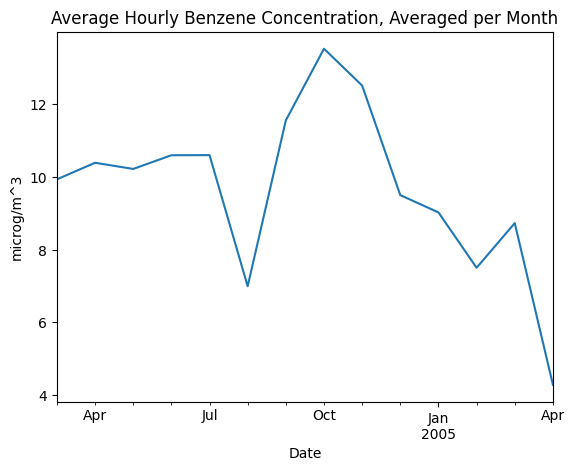

In [60]:
# Find the average over each month to make it a smoother line chart
benzene_means = air_data_clean.groupby("Month")["C6H6"].mean()
benzene_means.plot()
plt.title("Average Hourly Benzene Concentration, Averaged per Month")
plt.ylabel("microg/m^3")
plt.xlabel("Date")

I would be curious to know if the concentration of Benzene found in our atmosphere or in a city is continuously going up over time over a longer time horizon, and at what rate. Similarly, it would be interested to see if having a measure of Benzene at a given point in time gives us some sense of how much there would be after a given time period!

##**Tables and Plots of Benzene Against Temperature and Humidity**

We want to investigate benzene concentrations at different levels of temperature and humidity. Since temperature, relative humidity, and absolute humidity are stored as numeric variables in our dataset, we have to manually "bin" them into levels of our choosing.

`make_levels` is a function that takes in the following arguments:
* `percentiles`: a list of strings of row labels that identify which rows from our summary table we want to locate to find the corresponding statistics (like min, 25%, etc.)
* `variable`: the name of our column of interest, passed as a string
* `newvar`: the name of the new column we'll create in our dataset that has all numeric values from our variable of interest into our designated levels/bins
* `labels`: a list of strings that will serve as the values for our new variable, corresponding to each level

and returns a table with counts for each level in our new variable.

In [61]:
# I'm going to want to repeat this action, so I'm making a function
def make_levels(percentiles, variable, newvar, labels):
  """
  This function accepts "percentiles" as a string list of percentiles,
  from smallest to largest, later used to bin numerical data. We also
  enter our variable of interest as a string, so we locate which column's
  percentiles we're interested in. The function returns a numeric list
  of percentile values for that variable, in order.
  """
  # Use .loc to find the percentile values for a given variable, stored as a list
  my_bins = list(summary_tab.loc[percentiles, variable])
  # Use pd.cut to create bins based on the values found in "my_bins"
  air_data_clean[newvar] = pd.cut(air_data_clean[variable], bins = my_bins, labels = labels)

  # View the counts in each category of our new level-variable
  return air_data_clean[newvar].value_counts()

I test my function out on the variable temperature, simply defining "low" temperatures as ones below the 25th percentile of values, "high" as above the 75th percentile, and "medium" as the middle 50%.

In [62]:
# Test my function on temperature
make_levels(["min", "25%", "75%", "max"], "T", "temp_levels", ["Low", "Med.", "High"])

/tmp/ipython-input-1909490264.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean[newvar] = pd.cut(air_data_clean[variable], bins = my_bins, labels = labels)


,count
temp_levels,
Med.,4491
Low,2267
High,2232


Now that we know how many observations in our dataset fall into each of the temperature categories, let's find some statistics of benzene at each level of temperature. Below we have the mean, median, standard deviation, and count for benzene observations across temperature categories. We see that the mean concentrations at each temperature level is higher than the median for that level, which supports my suspicion that there are outliers in this dataset.

In [63]:
# Use crosstab to get numerical summaries for each level of temperature
pd.crosstab(
  air_data_clean.temp_levels,
  columns = ["stat" for _ in range(air_data_clean.shape[0])], # create a dummy variable for our column names
  values = air_data_clean.C6H6,
  aggfunc = ['mean', 'median', 'std', 'count'])

,mean,median,std,count
col_0,stat,stat,stat,stat
temp_levels,,,,
Low,7.837847,5.6,6.950084,2267
Med.,10.421287,8.2,7.863236,4491
High,11.682706,10.7,6.498439,2232


We can also visualize the shape of the benzene distribution for each temperature category. This creates three overlaid histograms of hourly averaged benzene concentrations for each temperature level.

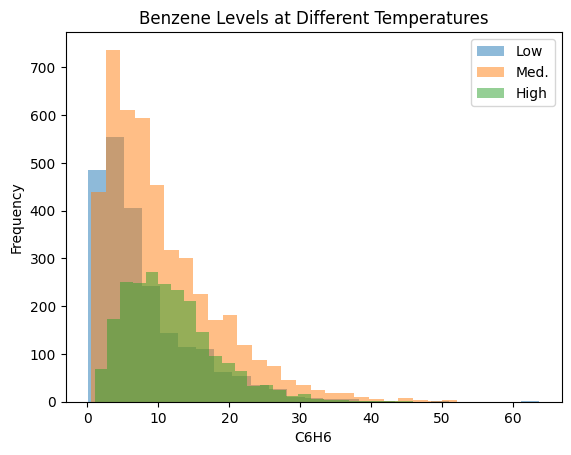

In [64]:
# Create histograms for benzene levels across different temperatures.

benzene_low = air_data_clean.loc[air_data_clean.temp_levels == "Low","C6H6"]
benzene_med = air_data_clean.loc[air_data_clean.temp_levels == "Med.", "C6H6"]
benzene_high = air_data_clean.loc[air_data_clean.temp_levels == "High", "C6H6"]

benzene_low.plot.hist(bins = 25, alpha = 0.5, label = "Low",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
benzene_med.plot.hist(bins = 25, alpha = 0.5, label = "Med.",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
benzene_high.plot.hist(bins = 25, alpha = 0.5, label = "High",
                   title = "Benzene Levels at Different Temperatures") \
                   .set(xlabel = "C6H6")
plt.legend()


Observe how the histogram peaks around slightly higher levels of benzene than for the other temperatures.

##**Testing Other Temperature Level Definitions**
My output above used a pretty conservative measure of "low/med./high" temperatures. Let's see how the data is distributed if I redefine the temperature levels based on the top and bottom 10%.

Since I plan to make more histograms like this, let's turn that chart into a function as well.

`hist_levels` is a function that takes in the following arguments:
* `levelvar`: this is the name of the categorical version of a numeric variable in our dataset, that has values assigned to different levels, passed as a string
* `numvar`: is the corresponding numeric variable, the values we want to plot, passed as a string
* `xlabel`: label for the x axis of the histogram, passed as a string
* `title`: string for the histogram title
* `bins`: number of bins for the plot, defaulting to 25
* `alpha`: transparency level for all plots, defaulting to 0.5

In [65]:
def hist_levels(levelvar, numvar, xlabel, title, bins = 25, alpha = 0.5,):
   """
   This function takes in the name of the level variable, corresponding numeric
   variable, number of histogram bins, transparency level for all three histograms,
   x axis label, and title, all as strings.
   """
   # Slice the dataset for the numeric variable at each level
   low = air_data_clean.loc[air_data_clean[levelvar] == "Low", numvar]
   med = air_data_clean.loc[air_data_clean[levelvar] == "Med.", numvar]
   high = air_data_clean.loc[air_data_clean[levelvar] == "High", numvar]

   # Create three overlaying histograms
   low.plot.hist(bins = bins, alpha = alpha, label = "Low", title = title) \
                   .set(xlabel = xlabel)
   med.plot.hist(bins = bins, alpha = alpha, label = "Med.") \
                   .set(xlabel = xlabel)
   high.plot.hist(bins = bins, alpha = alpha, label = "High") \
                   .set(xlabel = xlabel)
   plt.legend()

Below, I redefine my bins and replot benzene across the temperature levels.

In [66]:
# Next bins
make_levels(["min", "10%", "90%", "max"], "T", "temp_levels_extreme", ["Low", "Med.", "High"])

/tmp/ipython-input-1909490264.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean[newvar] = pd.cut(air_data_clean[variable], bins = my_bins, labels = labels)


,count
temp_levels_extreme,
Med.,7173
Low,925
High,892


In [67]:
# Use crosstab to get numerical summaries for each level of temperature
pd.crosstab(
  air_data_clean.temp_levels_extreme,
  columns = ["stat" for _ in range(air_data_clean.shape[0])], # create a dummy variable for our column names
  values = air_data_clean.C6H6,
  aggfunc = ['mean', 'median', 'std', 'count'])

,mean,median,std,count
col_0,stat,stat,stat,stat
temp_levels_extreme,,,,
Low,6.481189,4.7,6.137990,925
Med.,10.390632,8.4,7.680654,7173
High,11.344283,10.8,5.498605,892


Changing the bin values for temperature didn't appear to make any notable changes to the shape of the corresponding histograms, which is a helpful sanity check for our initial figure.

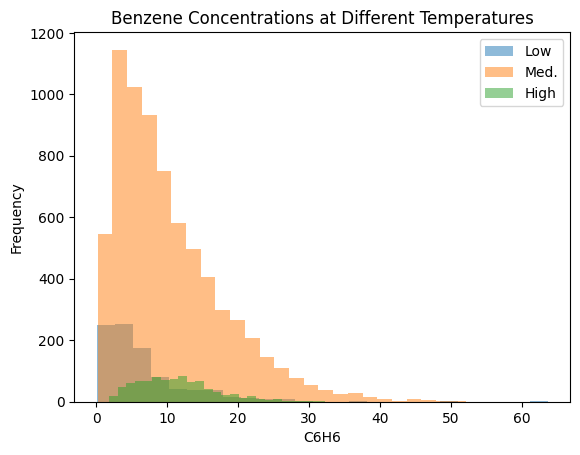

In [68]:
# Remake the histograms with our more extreme temperature categories.
hist_levels("temp_levels_extreme", "C6H6", xlabel = "C6H6", title = "Benzene Concentrations at Different Temperatures")

##**Investigating the Relationship between Humidity, Temperature, and Benzene Concentrations**

Let's introduce another factor: humidity! As with temperature, we'll construct some bins for low/medium/high relative humidity (RH) and absolute humidity (AH).

In [69]:
# Find our bin cutoff values by using our "get_binvals" function, with new percentiles
# Relative Humidity
make_levels(["min", "25%", "75%", "max"], "RH", "RH_levels", ["Low", "Med.", "High"])

/tmp/ipython-input-1909490264.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean[newvar] = pd.cut(air_data_clean[variable], bins = my_bins, labels = labels)


,count
RH_levels,
Med.,4500
Low,2250
High,2239


In [70]:
# Use crosstab to get numerical summaries for each level of temperature
pd.crosstab(
  air_data_clean.RH_levels,
  columns = ["stat" for _ in range(air_data_clean.shape[0])], # create a dummy variable for our column names
  values = air_data_clean.C6H6,
  aggfunc = ['mean', 'median', 'std', 'count'])

,mean,median,std,count
col_0,stat,stat,stat,stat
RH_levels,,,,
Low,10.798089,10.1,6.067935,2250
Med.,10.054889,7.9,7.934352,4500
High,9.417642,6.9,7.642639,2239


I find it notable that the benzene concentrations were the highest on average when relative humidity was "low", though the concentrations were the most variable (std) when humidity was "medium".

In [71]:
# Absolute Humidity
make_levels(["min", "25%", "75%", "max"], "AH", "AH_levels", ["Low", "Med.", "High"])

/tmp/ipython-input-1909490264.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  air_data_clean[newvar] = pd.cut(air_data_clean[variable], bins = my_bins, labels = labels)


,count
AH_levels,
Med.,4495
High,2248
Low,2247


In [72]:
# Use crosstab to get numerical summaries for each level of temperature
pd.crosstab(
  air_data_clean.AH_levels,
  columns = ["stat" for _ in range(air_data_clean.shape[0])], # create a dummy variable for our column names
  values = air_data_clean.C6H6,
  aggfunc = ['mean', 'median', 'std', 'count'])

,mean,median,std,count
col_0,stat,stat,stat,stat
AH_levels,,,,
Low,7.807877,6.0,6.466508,2247
Med.,10.466785,8.9,7.295692,4495
High,11.593950,9.3,8.124634,2248


For absolute humidity, however, the benzene concentrations were the most variable for the humidity level at which they were also highest on average.

Below is a crosstab of temperature and humidity levels, with the values being the standard deviation of benzene concentration. It looks like benzene measures were most variable when temperatures were medium and relative humidity was high. This table can't tell us the actual strength of that relationship, however, since there were also the most observations when temperatures were medium, and other factors that could have led to this observed variability.

In [73]:
pd.crosstab(
  air_data_clean.temp_levels,
  air_data_clean.RH_levels,
  values = air_data_clean.C6H6,
  aggfunc = ['std'])

std                    
RH_levels         Low      Med.      High
temp_levels                              
Low          5.668674  7.155096  6.883823
Med.         6.263855  8.073478  8.117203
High         5.740631  7.640806  4.886427

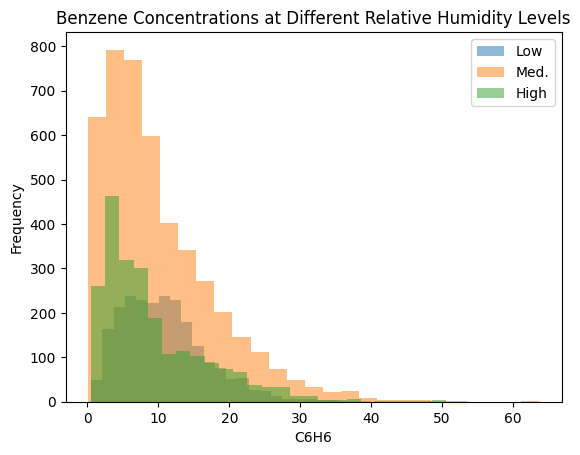

In [74]:
hist_levels("RH_levels", "C6H6", xlabel = "C6H6", title = "Benzene Concentrations at Different Relative Humidity Levels")

This figure shows that benzene levels are centered around higher concentrations when relative humidity is "low".

In [75]:
pd.crosstab(
  air_data_clean.temp_levels,
  air_data_clean.AH_levels,
  values = air_data_clean.C6H6,
  aggfunc = ['std'])

std                    
AH_levels         Low      Med.      High
temp_levels                              
Low          6.608812  7.485760       NaN
Med.         5.904050  7.656882  9.035498
High         5.127066  5.847360  7.113629

Note that there are no instances in this dataset where the temperature was "low", and the absolute humidity was "high". This makes sense, since relative humidity relates the amount of water in the air to how much it could hold at that temperature, whereas absolute humidity is just a measure of how much water is in the air, period. Again, we see that benzene concentration is most variable when temperatures are in the middle 50% and humidity is high.

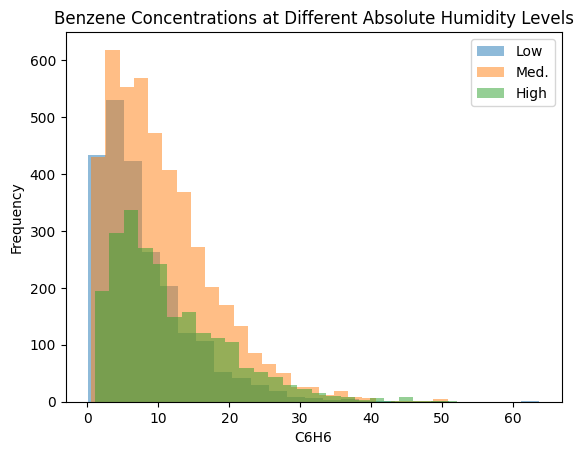

In [76]:
hist_levels("AH_levels", "C6H6", xlabel = "C6H6", title = "Benzene Concentrations at Different Absolute Humidity Levels")

The histograms for bezene appear to follow a more consistent shape across the levels of absolute humidity than they did for relative humidity.

##**Correlations with Other Gases**

Below we can calculate the correlation between the different gas concentrations observed in our dataset. Some notable correlations:

* `C6H6` and `NMHC_S2`: Benzene and non-metanic hydrocarbons are extremely positively correlated. This prompted a search to understand how these two are related, and it appears that benzene is a type of NMHC, which explains this relationship (https://kunakair.com/non-methane-hydrocarbons-nmhc/).
* `NOx_S3` and all the other gases: NOx_S3 demonstrates a negative correlation with the other gases. This would require a greater knowledge of chemistry or pollution for me to understand, but this implies that for these gases, a higher concentration is correlated with a lower concentration of NOx. Referring back to the variable information provided with the dataset, we can see that ground-truth NOx is measured in different units (ppb) than the other gases' ground truth (microg/m^3) which also impacts the interpretability here.



In [77]:
air_data_clean[["C6H6", "CO_S1", "NMHC_S2", "NOx_S3", "NO2_S4", "O3_S5"]].corr()

,C6H6,CO_S1,NMHC_S2,NOx_S3,NO2_S4,O3_S5
C6H6,1.000000,0.883795,0.981950,-0.735744,0.765731,0.865689
CO_S1,0.883795,1.000000,0.892964,-0.771938,0.682881,0.899324
NMHC_S2,0.981950,0.892964,1.000000,-0.796703,0.777254,0.880578
NOx_S3,-0.735744,-0.771938,-0.796703,1.000000,-0.538468,-0.796569
NO2_S4,0.765731,0.682881,0.777254,-0.538468,1.000000,0.591144
O3_S5,0.865689,0.899324,0.880578,-0.796569,0.591144,1.000000


In the chart below, we can use `NMHC_S2` as a proxy for benzene now that we know they are related, since our benzene variable is a "ground truth" reading, thus the magnitude is a lot smaller than our electric nose sensor readings of the other gases and we wouldn't be able to see benzene's pattern clearly. We see that the monthly average sensor readings for non-metanic hydro carbon follows a pattern most similar to O3 over time.

Text(0.5, 0, 'Date')

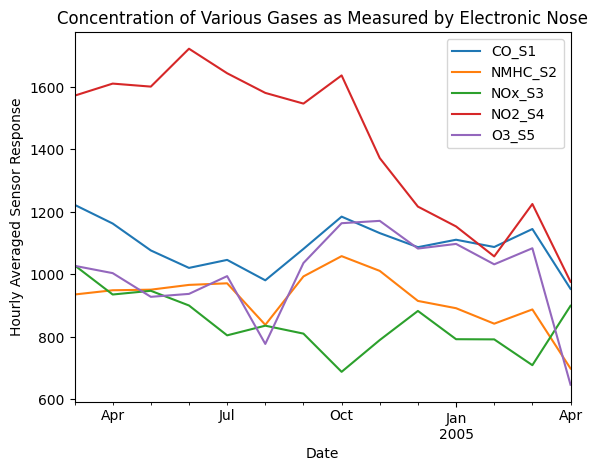

In [78]:
# Find the average over each month for the following gases
benzene_means = air_data_clean.groupby("Month")[["CO_S1", "NMHC_S2", "NOx_S3", "NO2_S4", "O3_S5"]].mean()
benzene_means.plot()
plt.title("Concentration of Various Gases as Measured by Electronic Nose")
plt.ylabel("Hourly Averaged Sensor Response")
plt.xlabel("Date")

Focusing back on benzene and the environmental factors that aren't other gases, we see that none of the correlations with benzene are strong/close to 1 at all. This calls into question any patterns we saw from our histograms at different levels of temperature or humidity.

In [79]:
#Temperature, relative humidity, absolute humidity
air_data_clean[["C6H6", "T", "RH", "AH"]].corr()

,C6H6,T,RH,AH
C6H6,1.000000,0.198956,-0.061681,0.167972
T,0.198956,1.000000,-0.578621,0.656397
RH,-0.061681,-0.578621,1.000000,0.167971
AH,0.167972,0.656397,0.167971,1.000000


##**Conclusion**
The tables and figures provided in this section have given us an overview of what kind of data are contained in this dataset, why this data might be of interest, and a cursory understanding of how these variables are related to one another. It would require more specialized knowledge in this specific field of study (quantifying pollutants in our atmosphere) to know exactly what kind of statistics and figures would be illuminating, but at least we know the basics about this dataset now!